Current step: 9999

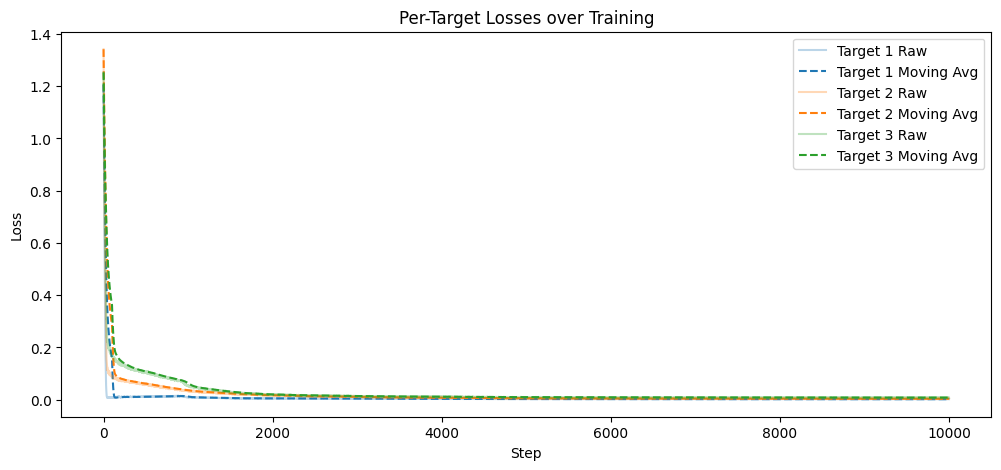

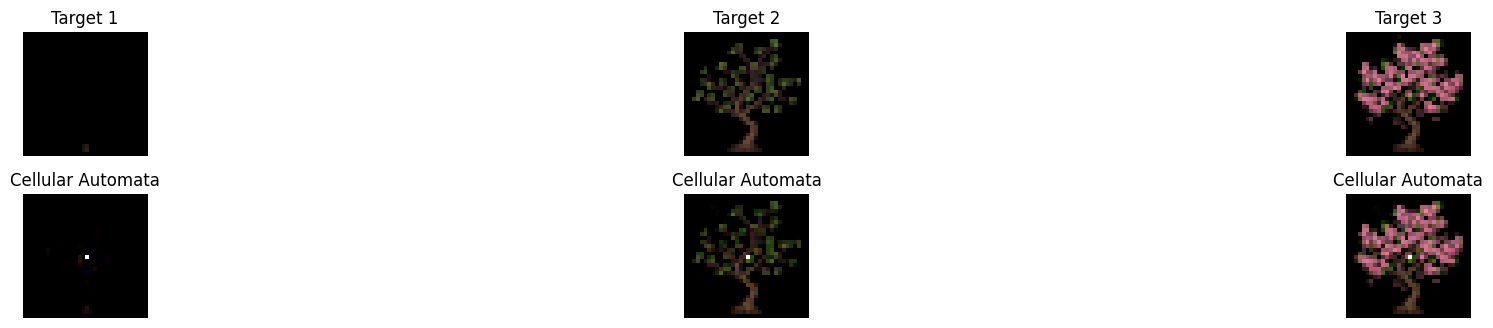

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
from IPython import display
import os
from typing import List, Tuple
import sys
import csv

# Constants
FIRE_RATE = 0.75
HIDDEN_CHANNELS = 128
BATCH_SIZE = 1
MOVING_AVG_WINDOW = 100
TARGET_WEIGHT = 1

TARGET_PATHS = [
    ('NCA3_32.png', 24, 1),
    ('NCA2_32.png', 32, 1),
    ('NCA_32.png', 48, 1),
]

CHECKPOINT_PATH = None
START_STEP = 0
NUM_STEPS = 10000  # total number of training steps

# Parameterize the folder where models are saved and loaded from
MODEL_SAVE_FOLDER = 'train_log_multi3_r32_hc128_fr75'
os.makedirs(MODEL_SAVE_FOLDER, exist_ok=True)

def preprocess_image(image_path):
    img = Image.open(image_path).convert('RGBA')
    data = img.getdata()
    new_data = []
    for item in data:
        if item[0] < 25 and item[1] < 25 and item[2] < 25:
            new_data.append((0, 0, 0, 0))
        else:
            new_data.append(item)
    img.putdata(new_data)
    return transforms.ToTensor()(img)

def load_targets(target_paths: List[Tuple[str, int, int]], device):
    target_paths.sort(key=lambda x: x[1])
    target_tensors = [preprocess_image(p).to(device) for p, _, _ in target_paths]
    target_steps = [s for _, s, _ in target_paths]
    target_durations = [d for _, _, d in target_paths]
    H, W = target_tensors[0].shape[1:]
    for t in target_tensors:
        assert t.shape[1:] == (H, W), "All target images must have the same dimensions"
    return target_tensors, target_steps, target_durations, H, W

class CAModel(nn.Module):
    def __init__(self, hidden_channels=HIDDEN_CHANNELS):
        super().__init__()
        self.hidden_channels = hidden_channels
        identify = torch.tensor([0.0, 1.0, 0.0])
        identify = torch.outer(identify, identify)
        dx = torch.outer(torch.tensor([1.0,2.0,1.0]), torch.tensor([-1.0,0.0,1.0]))/8.0
        dy = dx.T
        self.register_buffer('kernel', torch.stack([identify, dx, dy]).unsqueeze(1))
        self.update = nn.Sequential(
            nn.Conv2d(hidden_channels*3, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def perceive(self, x):
        k = self.kernel.repeat(1, self.hidden_channels, 1, 1)
        k = k.reshape(self.hidden_channels*3, 1, 3, 3)
        return F.conv2d(x, k, padding=1, groups=self.hidden_channels)
    
    def forward(self, x):
        y = self.perceive(x)
        dx = self.update(y)
        mask = (torch.rand_like(x) < FIRE_RATE).float()
        x = x + dx * mask
        return torch.clamp(x, 0.0, 1.0)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = CAModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.8, patience=500
)

# resume from checkpoint if available
current_step = START_STEP
if CHECKPOINT_PATH and os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    current_step = ckpt['step']
    print(f"Resuming from step {current_step}")

# load targets
target_tensors, target_steps, target_durations, H, W = load_targets(TARGET_PATHS, device)
num_targets = len(target_tensors)

# manually initialize seed tensor
seed_tensor = torch.zeros(4, H, W, device=device)
center_y, center_x = H // 2, W // 2
seed_tensor[:, center_y, center_x] = 1.0

# Prepare CSV logging
csv_path = os.path.join(MODEL_SAVE_FOLDER, 'loss_log.csv')
with open(csv_path, 'w', newline='') as csvfile:
    # Write header: step, total_loss, moving_avg, and per-target losses
    header = ['step', 'loss', 'moving_avg'] + [f'loss_target_{i+1}' for i in range(num_targets)]
    writer = csv.writer(csvfile)
    writer.writerow(header)

    total_losses = []
    per_target_losses = [[] for _ in range(num_targets)]  # List of lists for each target

    # Main training loop for a fixed number of steps
    for step in range(current_step, NUM_STEPS):
        current_step = step
        sys.stdout.write(f"\rCurrent step: {current_step}")
        sys.stdout.flush()

        # initialize state
        state = torch.zeros(BATCH_SIZE, HIDDEN_CHANNELS, H, W, device=device)
        state[:, :4] = seed_tensor.unsqueeze(0).repeat(BATCH_SIZE, 1, 1, 1)
        optimizer.zero_grad()
        x = state

        # run up to the last target window
        total_loss = torch.tensor(0.0, device=device)
        states_at_targets = []
        max_steps = target_steps[-1] + target_durations[-1]
        # For per-target loss tracking
        step_target_losses = [torch.tensor(0.0, device=device) for _ in range(num_targets)]

        for t in range(max_steps + 1):
            x = model(x)
            # capture state
            for i in range(num_targets):
                if t == target_steps[i] + target_durations[i] // 2:
                    states_at_targets.append(x.detach().clone())
            # accumulate MSE losses on RGBA channels
            for i in range(num_targets):
                if target_steps[i] <= t <= target_steps[i] + target_durations[i]:
                    tgt = target_tensors[i].unsqueeze(0)
                    mse = TARGET_WEIGHT * F.mse_loss(x[:, :4], tgt)
                    total_loss += mse
                    step_target_losses[i] += mse

        loss = total_loss
        total_losses.append(loss.item())
        for i in range(num_targets):
            per_target_losses[i].append(step_target_losses[i].item())

        # compute moving average
        if len(total_losses) >= MOVING_AVG_WINDOW:
            mov_avg = np.mean(total_losses[-MOVING_AVG_WINDOW:])
        else:
            mov_avg = np.mean(total_losses)
        # Write step, total loss, moving avg, and per-target losses
        row = [current_step, loss.item(), mov_avg] + [step_target_losses[i].item() for i in range(num_targets)]
        writer.writerow(row)
        csvfile.flush()

        # backpropagation and update
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        scheduler.step(loss)

    # After training is complete, save final plots:

    # 1) Loss curve (per target)
    fig1 = plt.figure(figsize=(12, 5))
    colors = plt.cm.tab10.colors
    for i in range(num_targets):
        # Raw per-target loss
        plt.plot(per_target_losses[i], alpha=0.3, label=f'Target {i+1} Raw', color=colors[i % len(colors)])
        # Moving average per-target loss
        moving_avgs = [np.mean(per_target_losses[i][max(0, j - MOVING_AVG_WINDOW): j + 1])
                       for j in range(len(per_target_losses[i]))]
        plt.plot(moving_avgs, label=f'Target {i+1} Moving Avg', color=colors[i % len(colors)], linestyle='--')
    plt.title('Per-Target Losses over Training')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.legend()
    fig1.savefig(os.path.join(MODEL_SAVE_FOLDER, 'final_loss_plot.png'))

    # 2) Final target vs CA states
    fig2 = plt.figure(figsize=(20, 5))
    for i in range(num_targets):
        plt.subplot(3, num_targets, i + 1)
        plt.imshow(target_tensors[i][:3].permute(1, 2, 0).cpu())
        plt.title(f'Target {i+1}')
        plt.axis('off')
        if i < len(states_at_targets):
            plt.subplot(3, num_targets, i + 1 + num_targets)
            plt.imshow(states_at_targets[i][0, :3].cpu().permute(1, 2, 0))
            plt.title('Cellular Automata')
            plt.axis('off')
    plt.tight_layout()
    fig2.savefig(os.path.join(MODEL_SAVE_FOLDER, 'final_states.png'))

    # Save the final model after training is complete
    torch.save({
        'step': current_step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, os.path.join(MODEL_SAVE_FOLDER, 'model_final.pt'))

In [42]:
# Import additional required libraries
from matplotlib.animation import FuncAnimation
import tqdm
from IPython.display import HTML, display

# Load models from different checkpoints
models = []
model_steps = [800]  # Adjust steps based on your saved checkpoints

# Load models with error handling
for step in model_steps:
    checkpoint_path = f'train_log_multi3_r16_hc32_fr1/model_final.pt'
    try:
        ca = CAModel().to(device)
        checkpoint = torch.load(checkpoint_path, map_location=device)
        ca.load_state_dict(checkpoint['model_state_dict'])
        ca.eval()
        models.append(ca)
    except FileNotFoundError:
        print(f"Could not find model for step {step} at {checkpoint_path}")
        continue

if not models:
    print("No models were loaded successfully")
else:
    H, W = 16, 16
    # Determine the number of channels expected by the CA model
    n_channels = models[0].hidden_channels

    # Prepare initial seed tensor (4 RGBA channels)
    seed_tensor = torch.zeros(4, H, W, device=device)
    cy, cx = H // 2, W // 2
    seed_tensor[:, cy, cx] = 1.0

    # Initialize global state: shape (num_models, n_channels, H, W)
    global state
    state = torch.zeros(len(models), n_channels, H, W, device=device)
    # Seed the first 4 channels for each model
    state[:, :4] = seed_tensor.unsqueeze(0)

    # Create visualization
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)

    # Initialize the image plots
    img_plot_rgba = ax1.imshow(state[0, :3].permute(1, 2, 0).cpu().clamp(0, 1))
    img_plot_alpha = ax2.imshow(state[0, 3].cpu(), cmap='gray', vmin=0, vmax=1)
    ax1.axis('off'); ax2.axis('off')
    ax1.set_title('RGBA Channels')
    ax2.set_title('Alpha Channel')
    plt.close(fig)

    def update(frame):
        global state
        # Optionally re-seed at the first frame
        if frame == 0:
            state = torch.zeros(len(models), n_channels, H, W, device=device)
            state[:, :4] = seed_tensor.unsqueeze(0)

        # Step each model forward
        new_states = []
        with torch.no_grad():
            for ca, st in zip(models, state):
                out = ca(st.unsqueeze(0))
                new_states.append(out[0])
        state = torch.stack(new_states, dim=0)

        # Refresh the plots with the first model's RGBA and alpha
        rgba_img = state[0, :3].permute(1, 2, 0).cpu().clamp(0, 1)
        alpha_img = state[0, 3].cpu()
        img_plot_rgba.set_data(rgba_img)
        img_plot_alpha.set_data(alpha_img)

        ax1.set_title(f'RGBA Channels - Frame {frame}')
        ax2.set_title(f'Alpha Channel - Frame {frame}')
        return [img_plot_rgba, img_plot_alpha]

    # Create and display the animation
    anim = FuncAnimation(fig, update, frames=25, interval=300, blit=True)
    display(HTML(anim.to_jshtml()))

In [ ]:
# Import additional required libraries
from matplotlib.animation import FuncAnimation
import tqdm
from IPython.display import HTML, display

# Load models from different checkpoints
models = []
model_steps = [800]  # Adjust steps based on your saved checkpoints

# Load models with error handling
for step in model_steps:
    checkpoint_path = f'train_log_multi_r32_hc128_fr1/model_final.pt'
    try:
        ca = CAModel().to(device)
        checkpoint = torch.load(checkpoint_path, map_location=device)
        ca.load_state_dict(checkpoint['model_state_dict'])
        ca.eval()
        models.append(ca)
    except FileNotFoundError:
        print(f"Could not find model for step {step} at {checkpoint_path}")
        continue

if not models:
    print("No models were loaded successfully")
else:
    H, W = 32, 32
    # Determine the number of channels expected by the CA model
    n_channels = models[0].hidden_channels

    # Prepare initial seed tensor (4 RGBA channels)
    seed_tensor = torch.zeros(4, H, W, device=device)
    cy, cx = H // 2, W // 2
    seed_tensor[:, cy, cx] = 1.0

    # Initialize global state: shape (num_models, n_channels, H, W)
    global state
    state = torch.zeros(len(models), n_channels, H, W, device=device)
    # Seed the first 4 channels for each model
    state[:, :4] = seed_tensor.unsqueeze(0)

    # Create visualization
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)

    # Initialize the image plots
    img_plot_rgba = ax1.imshow(state[0, :3].permute(1, 2, 0).cpu().clamp(0, 1))
    img_plot_alpha = ax2.imshow(state[0, 3].cpu(), cmap='gray', vmin=0, vmax=1)
    ax1.axis('off'); ax2.axis('off')
    ax1.set_title('RGBA Channels')
    ax2.set_title('Alpha Channel')
    plt.close(fig)

    def update(frame):
        global state
        # Optionally re-seed at the first frame
        if frame == 0:
            state = torch.zeros(len(models), n_channels, H, W, device=device)
            state[:, :4] = seed_tensor.unsqueeze(0)

        # Step each model forward
        new_states = []
        with torch.no_grad():
            for ca, st in zip(models, state):
                out = ca(st.unsqueeze(0))
                new_states.append(out[0])
        state = torch.stack(new_states, dim=0)

        # Refresh the plots with the first model's RGBA and alpha
        rgba_img = state[0, :3].permute(1, 2, 0).cpu().clamp(0, 1)
        alpha_img = state[0, 3].cpu()
        img_plot_rgba.set_data(rgba_img)
        img_plot_alpha.set_data(alpha_img)

        ax1.set_title(f'RGBA Channels - Frame {frame}')
        ax2.set_title(f'Alpha Channel - Frame {frame}')
        return [img_plot_rgba, img_plot_alpha]

    # Create and display the animation
    anim = FuncAnimation(fig, update, frames=33, interval=300, blit=True)
    display(HTML(anim.to_jshtml()))